# Stanford CME 241 (Winter 2026) - Assignment 3

**Due: Friday, February 27 @ 11:59 PM PST on Gradescope.**

Assignment instructions:
- Make sure each of the subquestions have answers
- Ensure that group members indicate which problems they're in charge of
- Show work and walk through your thought process where applicable
- Empty code blocks are for your use, so feel free to create more under each section as needed
- Document code with light comments (i.e. 'this function handles visualization')

Submission instructions:
- When complete, fill out your publicly available GitHub repo file URL and group members below, then export or print this .ipynb file to PDF and upload the PDF to Gradescope.

*Link to this ipynb file in your public GitHub repo (replace below URL with yours):* 

https://github.com/TommySini/RL-book/blob/master/assingments/assignment3.ipynb

*Group members (replace below names with people in your group):* 
- Tommaso Sini
- Anthony Viverito

## Imports

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize_scalar
from typing import Iterable, Iterator, Mapping, TypeVar, Callable, Sequence, Tuple, Dict
from rl.distribution import Categorical
from rl.markov_process import FiniteMarkovRewardProcess
from rl.chapter10.prediction_utils import compare_td_and_mc
X = TypeVar('X')
S = TypeVar('S')

## Question 1: Milk Vendor Optimization Problem (Led by Tommy Sini)

You are a milk vendor and your task is to bring to your store a supply (denoted $S \in \mathbb{R}$) of milk volume in the morning that will give you the best profits. You know that the demand for milk throughout the course of the day is a probability distribution function $f$ (for mathematical convenience, assume people can buy milk in volumes that are real numbers, hence milk demand $x \in \mathbb{R}$ is a continuous variable with a probability density function). 

For every extra gallon of milk you carry at the end of the day (supply $S$ exceeds random demand $x$), you incur a cost of $h$ (effectively the wasteful purchases amounting to the difference between your purchase price and the end-of-day discount disposal price since you are not allowed to sell the same milk the next day). For every gallon of milk that a customer demands that you don’t carry (random demand $x$ exceeds supply $S$), you incur a cost of $p$ (effectively the missed sales revenue amounting to the difference between your sales price and purchase price). 

Your task is to identify the optimal supply $S$ that minimizes your **Expected Cost** $g(S)$, given by:

$$
g_1(S) = \mathbb{E}[\max(x - S, 0)] = \int_{S}^{\infty} (x - S) \cdot f(x) \, dx
$$

$$
g_2(S) = \mathbb{E}[\max(S - x, 0)] = \int_{-\infty}^{S} (S - x) \cdot f(x) \, dx
$$

$$
g(S) = p \cdot g_1(S) + h \cdot g_2(S)
$$

---

### Part (A): Analytical Optimization

1. **Derive the first-order condition (FOC)** for minimizing the expected cost $g(S)$.

2. **Solve the FOC** to express the optimal supply $S^*$ in terms of the given parameters: $p$, $h$, and the demand distribution $f(x)$. (*Hint*: Pay attention to the balance between the costs of overstocking and understocking)

3. **Interpretation**: Provide an interpretation of the condition you derived. What does the balance between $p$ and $h$ imply about the optimal supply $S^*$?

---

### Part (B): Special Case Analysis

1. Consider the case where the demand $x$ follows an **exponential distribution** with parameter $\lambda > 0$. That is, $f(x) = \lambda e^{-\lambda x}$ for $x \geq 0$.
    - Derive an explicit expression for the optimal supply $S^*$.
    
2. Consider the case where the demand $x$ follows a **normal distribution** with mean $\mu$ and variance $\sigma^2$, i.e., $x \sim \mathcal{N}(\mu, \sigma^2)$. 
    - Set up the integral for $g(S)$ and describe how it relates to the **cumulative distribution function (CDF)** of the normal distribution.
    - Provide an interpretation of how changes in $\mu$ and $\sigma$ influence the optimal $S^*$. 

---

### Part (C): Framing as a Financial Options Problem

1. Frame the milk vendor’s problem as a **portfolio of call and put options**:
    - Identify the analog of the “strike price” and “underlying asset.”
    - Explain which part of the cost function $g_1(S)$ or $g_2(S)$ corresponds to a call option and which part to a put option.
    - What do $p$ and $h$ represent in this options framework?

2. Explain how this framing could be used to derive the optimal supply $S^*$ if solved using financial engineering concepts.

---

### Part (D): Numerical Solution and Simulation

1. **Numerical Solution**: Write a Python function that numerically estimates the optimal $S^*$ using an iterative search or numerical optimization method. 

2. **Simulation**: Generate random samples of milk demand from an exponential distribution and simulate the total costs for different values of $S$. Plot the costs against $S$ and visually identify the optimal $S$.

### Part (A) Answer

### 1.

The expected cost is

$$
g(S) = p\,g_1(S) + h\,g_2(S),
$$

where

$$
g_1(S) = \int_S^{\infty} (x - S) f(x)\,dx,
\qquad
g_2(S) = \int_{-\infty}^{S} (S - x) f(x)\,dx.
$$

Differentiate $g_1(S)$ using Leibniz’ rule:

$$
\frac{d}{dS} g_1(S)
= \frac{d}{dS}\int_S^{\infty}(x-S)f(x)\,dx.
$$

The boundary term vanishes since $(S-S)=0$, and

$$
\frac{\partial}{\partial S}[(x-S)f(x)] = -f(x).
$$

Thus,
$$
g_1'(S) = -\int_S^{\infty} f(x)\,dx = -(1 - F(S)),
$$
where $F(S)$ is the cumulative distribution function.

Similarly,

$$
\frac{d}{dS} g_2(S)
= \frac{d}{dS}\int_{-\infty}^{S}(S-x)f(x)\,dx,
$$

and since
$$
\frac{\partial}{\partial S}[(S-x)f(x)] = f(x),
$$

we obtain
$$
g_2'(S) = \int_{-\infty}^{S} f(x)\,dx = F(S).
$$

Differentiating the total expected cost gives

$$
g'(S) = p\,g_1'(S) + h\,g_2'(S)
= -p(1 - F(S)) + hF(S).
$$

The first-order condition for the optimal supply $S^*$ is therefore

$$
\boxed{-p(1 - F(S^*)) + hF(S^*) = 0.}
$$

### 2.
Starting from the FOC from part (1),

$$
-p(1-F(S^*)) + hF(S^*) = 0.
$$

Rearrange:

$$
hF(S^*) = p(1 - F(S^*)) = p - pF(S^*),
$$

so

$$
(h+p)F(S^*) = p
\quad\Longrightarrow\quad
F(S^*) = \frac{p}{p+h}.
$$

Therefore the optimal supply is the quantile of the demand distribution at probability $\frac{p}{p+h}$:

$$
\boxed{\,S^* = F^{-1}\!\left(\frac{p}{p+h}\right)\, }.
$$

Equivalently, $S^*$ is chosen so that

$$
\mathbb{P}(X \le S^*) = \frac{p}{p+h}
\qquad\text{and}\qquad
\mathbb{P}(X > S^*) = \frac{h}{p+h}.
$$

### 3.
The condition

$$
F(S^*) = \frac{p}{p+h}
$$

means that the optimal supply balances the costs of understocking and overstocking. The parameter $p$ represents the cost of understocking, or the loss incurred when demand exceeds supply, while $h$ represents the cost of overstocking, or the loss from unsold inventory. The optimal supply $S^*$ is chosen so that the probability that demand is less than or equal to supply equals $\frac{p}{p+h}$. If $p$ is large relative to $h$, understocking is more costly, so the ratio $\frac{p}{p+h}$ is closer to 1 and the optimal supply increases in order to reduce the chance of running out. If $h$ is large relative to $p$, overstocking is more costly, so the ratio decreases and the optimal supply is lower to avoid excess inventory. Thus, the optimal supply corresponds to a demand quantile determined by the relative magnitudes of the two costs.


### Part (B) Answer

### 1.

If demand $X$ is exponential with parameter $\lambda>0$, then for $x\ge 0$,

$$
f(x)=\lambda e^{-\lambda x}, \qquad F(x)=1-e^{-\lambda x}.
$$

From Part (A), the optimal supply satisfies

$$
F(S^*)=\frac{p}{p+h}.
$$

So

$$
1-e^{-\lambda S^*}=\frac{p}{p+h}
\quad\Longrightarrow\quad
e^{-\lambda S^*}=\frac{h}{p+h}
\quad\Longrightarrow\quad
\boxed{\,S^*=\frac{1}{\lambda}\ln\!\left(\frac{p+h}{h}\right)\, }.
$$


### 2.

If demand $X$ is normal, $X\sim\mathcal N(\mu,\sigma^2)$, then its CDF can be written using the standard normal CDF $\Phi$ as

$$
F(S)=\Phi\!\left(\frac{S-\mu}{\sigma}\right),
\qquad
f(x)=\frac{1}{\sigma\sqrt{2\pi}}\exp\!\left(-\frac{(x-\mu)^2}{2\sigma^2}\right).
$$

The expected cost is

$$
g(S)=p\int_S^{\infty}(x-S)f(x)\,dx \;+\; h\int_{-\infty}^{S}(S-x)f(x)\,dx,
$$

and the FOC from Part (A) becomes

$$
F(S^*)=\Phi\!\left(\frac{S^*-\mu}{\sigma}\right)=\frac{p}{p+h}.
$$

Thus,

$$
\boxed{\,S^*=\mu+\sigma\,\Phi^{-1}\!\left(\frac{p}{p+h}\right)\, }.
$$

Increasing $\mu$ shifts the entire demand distribution to the right, so $S^*$ increases one-for-one with $\mu$. Changing $\sigma$ changes how spread out demand is; the effect on $S^*$ is linear through the factor $\sigma\,\Phi^{-1}\!\left(\frac{p}{p+h}\right)$. In particular, if $\frac{p}{p+h}>\tfrac12$ (understocking is relatively more costly), then $\Phi^{-1}\!\left(\frac{p}{p+h}\right)>0$ and larger $\sigma$ increases $S^*$, while if $\frac{p}{p+h}<\tfrac12$, then the quantile is negative and larger $\sigma$ decreases $S^*$.

### Part (C) Answer

### 1.

Let the random demand be the underlying variable $X$ (analogous to the underlying asset price), and let the chosen supply level $S$ play the role of the strike. The two “mismatch” terms in the cost function are exactly the standard option payoffs:

$$
g_1(S)=\mathbb E[(X-S)^+] \quad \text{and} \quad g_2(S)=\mathbb E[(S-X)^+],
$$

where $(y)^+=\max\{y,0\}$.

The term $g_1(S)$ matches the payoff of a call option on $X$ with strike $S$, because it is positive only when $X>S$ and equals $X-S$ in that region. The term $g_2(S)$ matches the payoff of a put option on $X$ with strike $S$, because it is positive only when $X<S$ and equals $S-X$ there.

In this analogy, $p$ is the per-unit weight (or “position size”) on the call payoff, representing the marginal cost of understocking, and $h$ is the per-unit weight on the put payoff, representing the marginal cost of overstocking. Thus the expected cost can be viewed as the value of a portfolio that is long $p$ calls and long $h$ puts on the random demand $X$, all with strike $S$:

$$
g(S)=p\,\mathbb E[(X-S)^+] + h\,\mathbb E[(S-X)^+].
$$


### 2.

In option-pricing language, choosing $S$ is choosing the strike that minimizes the value of this call–put portfolio. The key fact is that the derivative of an expected call payoff with respect to strike is the negative tail probability and the derivative of an expected put payoff with respect to strike is the CDF:

$$
\frac{d}{dS}\mathbb E[(X-S)^+] = -(1-F(S)), 
\qquad
\frac{d}{dS}\mathbb E[(S-X)^+] = F(S).
$$

So the marginal change in the portfolio value when increasing the strike is

$$
g'(S)=p\big(-(1-F(S))\big)+hF(S).
$$

Setting marginal cost to zero yields the same “critical fractile” condition:

$$
-p(1-F(S^*)) + hF(S^*)=0
\quad\Longrightarrow\quad
F(S^*)=\frac{p}{p+h}.
$$

Interpreted financially, the optimal strike is chosen so that the weighted sensitivity of the call component to the strike exactly offsets the weighted sensitivity of the put component, which is the same economic balance between understocking and overstocking from Parts (A) and (B).

### Part (D) Answer

In [6]:
# simulation parameters
p = 5  # Cost of understocking (per unit)
h = 2  # Cost of overstocking (per unit)
lambda_param = 1.0  

# Probability density function for demand
def demand_pdf(x):
    return lambda_param * np.exp(-lambda_param * x) if x >= 0 else 0.0

# Cumulative distribution function for demand
def demand_cdf(x):
    return 1.0 - np.exp(-lambda_param * x) if x >= 0 else 0.0

# Expected cost function g(S)
def expected_cost(S):
    g1 = p * (np.exp(-lambda_param * S) / lambda_param)
    g2 = h * (S - demand_cdf(S) / lambda_param)

    return g1 + g2

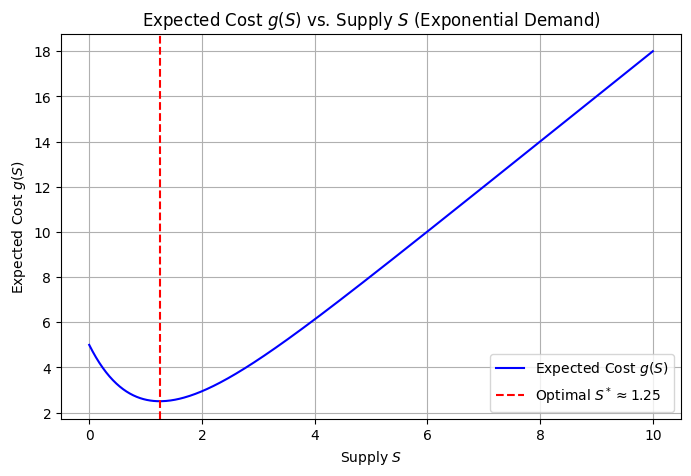

np.float64(1.252763051167479)

In [7]:
result = minimize_scalar(expected_cost, bounds=(0, 10), method='bounded')
optimal_S = result.x

# Simulation of costs
S_values = np.linspace(0, 10, 500)
costs = [expected_cost(S) for S in S_values]

# Plotting the costs against S
plt.figure(figsize=(8, 5))
plt.plot(S_values, costs, label="Expected Cost $g(S)$", color='blue')
plt.axvline(optimal_S, color='red', linestyle='--', label=f"Optimal $S^* \\approx {optimal_S:.2f}$")
plt.xlabel("Supply $S$")
plt.ylabel("Expected Cost $g(S)$")
plt.title("Expected Cost $g(S)$ vs. Supply $S$ (Exponential Demand)")
plt.legend()
plt.grid(True)
plt.show()

optimal_S

## Question 2: Car Sales (Led By: Tommy Sini)

You must sell your car within a finite window of $N$ days. At the beginning of each day $t \in \{1, \dots, N\}$, you receive a single offer $X_t$ from a dealership, where $\{X_t\}$ are i.i.d. draws from a known continuous distribution $Q$ supported on $[m, M]$, with $0 < m < M$.

After observing $X_t$, you must immediately choose whether to **accept** or **reject** the offer:

- If you **accept** on day $t$, you sell the car immediately and receive payoff $X_t$. The process then terminates.
- If you **reject** on day $t < N$, you keep the car, pay a parking cost $c \ge 0$ at the end of that day, and proceed to day $t+1$.
- On day $N$, you must accept the offer (i.e., rejecting is not allowed).

Your objective is to maximize the expected **net payoff**, defined as the sale price minus the total parking costs paid before the sale.

---

### Part (A): MDP Modeling

Model this problem as a finite-horizon **Markov Decision Process (MDP)**. Clearly specify:

1. **States**
2. **Actions**
3. **Rewards**
4. **State-transition probabilities**
5. **Discount factor** (use $\gamma = 1$)

Also state whether this MDP is finite- or infinite-horizon, episodic or continuing, and whether it is time-homogeneous.

---

### Part (B): Structure of the Optimal Policy

Let $V_t$ denote the optimal value function when there are $t$ days remaining (before observing the offer).

1. Write down the Bellman recursion for $V_t$.
2. Show that the optimal policy is a **time-dependent threshold policy**: that is, there exists a reservation price $r_t$ such that it is optimal to accept an offer $x$ if and only if $x \ge r_t$.
3. Express the threshold $r_t$ in terms of $V_{t-1}$ and $c$.

(You may leave expectations with respect to $Q$ written in integral or expectation form. A closed-form solution for general $Q$ is not required.)

---

### Part (C): Special Case (No Integrals)

Now consider the special case where $c = 0$ and $Q = \text{Uniform}[m, M]$.

1. Write the recursion for $V_t$ explicitly.
2. Provide the optimal policy in as closed-form a way as possible. Your policy may depend on recursively defined coefficients, but your final expressions should contain **no integrals**.


### Part (A) Answer

### 1. States
A convenient state is the number of days remaining together with whether the process has already ended. Let
$$
s_t = t \in \{1,2,\dots,N\}
$$
denote “$t$ days remaining before seeing today’s offer,” and include a terminal absorbing state $s=\text{Terminal}$ after the car is sold. After observing the offer, you can equivalently treat the state as $(t,x)$, but it is enough to keep $t$ as the pre-offer state since offers are i.i.d. from $Q$ each day.

### 2. Actions
After observing the offer $x$ on a day with $t\ge 2$ days remaining, the action set is
$$
A = \{\text{Accept},\ \text{Reject}\}.
$$
On the last day ($t=1$, equivalently day $N$), rejecting is not allowed, so
$$
A(t=1)=\{\text{Accept}\}.
$$

### 3. Rewards
If you accept an observed offer $x$, you sell immediately and receive reward
$$
R(\text{Accept}\mid x)=x.
$$
If you reject (only allowed when $t\ge 2$), you keep the car and pay the parking cost at the end of the day, so the immediate reward is
$$
R(\text{Reject})=-c.
$$
(There is no additional reward from continuing besides the future offer opportunity encoded in the value function.)

### 4. State-transition probabilities
Offers are i.i.d. draws from $Q$ each day. If you accept, the process transitions to the terminal state with probability 1:
$$
P(\text{Terminal}\mid t,x,\text{Accept}) = 1.
$$
If you reject at a state with $t\ge 2$, you move deterministically to $t-1$ days remaining:
$$
P(t-1 \mid t,x,\text{Reject}) = 1,
$$
and then a new offer is drawn at the start of the next day according to $Q$.

### 5. Discount factor
Use
$$
\gamma = 1.
$$

This is a finite-horizon ($N$-step) MDP, episodic (it terminates upon acceptance, and acceptance is forced by day $N$), and time-inhomogeneous because the action set/termination constraint depends on how many days remain (the last day differs from earlier days).


### Part (B) Answer

Let $V_t$ be the optimal value when there are $t$ days remaining, before observing the offer. On a day with $t$ days remaining, you observe $X\sim Q$ and then choose accept/reject.

### 1. Bellman recursion
For $t\ge 2$,
$$
V_t = \mathbb E\left[\max\left\{X,\ -c + V_{t-1}\right\}\right], \quad X\sim Q.
$$
For the base case (last day), you must accept, so
$$
V_1 = \mathbb E[X], \quad X\sim Q.
$$

### 2. Threshold (reservation price) structure
Fix $t\ge 2$ and suppose you observe offer $x$. If you accept, your payoff is $x$. If you reject, your payoff is $-c + V_{t-1}$, since you pay $c$ and then continue optimally with $t-1$ days left. Therefore, accepting is optimal exactly when
$$
x \ge -c + V_{t-1}.
$$
This shows the optimal policy is a time-dependent threshold policy.

### 3. Threshold in terms of $V_{t-1}$ and $c$
Define the reservation price (threshold) $r_t$ by indifference between accepting and rejecting:
$$
r_t = -c + V_{t-1}.
$$
Then the optimal rule for $t\ge 2$ is: accept if and only if $x \ge r_t$, and on $t=1$ accept always.

### Part (C) Answer

Here $X\sim \text{Uniform}[m,M]$, so $\mathbb E[X]=\frac{m+M}{2}$.

### 1. Recursion for $V_t$ explicitly
With $c=0$, the recursion from Part (B) becomes
$$
V_t = \mathbb E\left[\max\left\{X,\ V_{t-1}\right\}\right], \qquad V_1=\frac{m+M}{2},
$$
with $X\sim \text{Uniform}[m,M]$.

Using the threshold form, we accept when $X\ge V_{t-1}$. Since $V_{t-1}\in[m,M]$, we can compute this expectation directly (no integrals in the final expression):
$$
V_t
= \mathbb E[X\mathbf 1_{\{X\ge V_{t-1}\}}] + V_{t-1}\,\mathbb P(X< V_{t-1}).
$$
For a uniform on $[m,M]$,
$$
\mathbb P(X< a)=\frac{a-m}{M-m},
\qquad
\mathbb E[X\mid X\ge a]=\frac{a+M}{2},
\qquad
\mathbb P(X\ge a)=\frac{M-a}{M-m}.
$$
Substitute $a=V_{t-1}$ to get the closed recursion
$$
V_t
= V_{t-1}\frac{V_{t-1}-m}{M-m} \;+\; \frac{V_{t-1}+M}{2}\cdot \frac{M-V_{t-1}}{M-m}.
$$
This simplifies to
$$
\boxed{
V_t
= \frac{M^2 + V_{t-1}^2 - 2mV_{t-1}}{2(M-m)},
\qquad
V_1=\frac{m+M}{2}.
}
$$

### 2. Optimal policy in closed form (no integrals)
From Part (B), with $c=0$ the reservation price is
$$
r_t = V_{t-1}.
$$
So the optimal policy is: with $t\ge 2$ days remaining, accept the observed offer $x$ if and only if
$$
\boxed{x \ge V_{t-1},}
$$
where the sequence $\{V_t\}$ is generated by
$$
V_1=\frac{m+M}{2},
\qquad
V_t=\frac{M^2 + V_{t-1}^2 - 2mV_{t-1}}{2(M-m)} \ \ (t\ge 2).
$$
On the last day ($t=1$), accept automatically.

## Question 3: Constrained Consumption (Led By: Anthony Viverito)

Consider the following discrete-time MDP for constrained consumption. At $t = 0$, the agent is given a finite amount $x_0 \in \mathbb{R}^+$ of a resource. In each time period, the agent can choose to consume any amount of the resource, with the consumption denoted as $c \in [0, x]$ where $x$ is the amount of the resource remaining at the start of the time period. This consumption results in a reduction of the resource at the start of the next time period:  
$$x' = x - c.$$  

Consuming a quantity $c$ of the resource provides a utility of consumption equal to $U(c)$, and we adopt the **CRRA utility function**:  
$$
U(c) = \frac{c^{1 - \gamma}}{1 - \gamma}, \quad (\gamma > 0, \gamma \neq 1)
$$

Our goal is to maximize the aggregate discounted utility of consumption until the resource is completely consumed. We assume a discount factor of $\beta \in (0, 1)$ when discounting the utility of consumption over any single time period. Assume parameters are such that the value function is finite.

We model this as a **discrete-time, continuous-state-space, continuous-action-space, stationary, deterministic MDP**, and so our goal is to solve for the **Optimal Value Function** and associated **Optimal Policy**, which will give us the optimal consumption trajectory of the resource. Since this is a stationary MDP, the **State** is simply the amount $x$ of the resource remaining at the start of a time period. The **Action** is the consumption quantity $c$ in that time period. The **Reward** for a time period is $U(c)$ when the consumption in that time period is $c$. The discount factor over each single time period is $\beta$.

We assume that the **Optimal Policy** is given by:  
$$
c^* = \theta^* \cdot x \quad \text{for some } \theta^* \in [0, 1].
$$

---

### Part (A): Closed-form Expression for $V_\theta(x)$

Our first step is to consider a fixed deterministic policy, given by:  
$$c = \theta \cdot x \quad \text{for some fixed } \theta \in [0, 1].$$  
Derive a closed-form expression for the **Value Function** $V_\theta(x)$ for a fixed deterministic policy, given by $c = \theta \cdot x$. Specifically, you need to express $V_\theta(x)$ in terms of $\beta$, $\gamma$, $\theta$, and $x$.

---

### Part (B): Solving for $\theta^*$

Use this closed-form expression for $V_\theta(x)$ to solve for the $\theta^*$ which maximizes $V_\theta(x)$ (thus fetching us the **Optimal Policy** given by $c^* = \theta^* \cdot x$).

---

### Part (C): Expression for $V^*(x)$

Use this expression for $\theta^*$ to obtain an expression for the **Optimal Value Function** $V^*(x)$ in terms of only $\beta$, $\gamma$, and $x$.

---

### Part (D): Validation of the Bellman Equation

Validate that the **Optimal Policy** (derived in part B) and **Optimal Value Function** (derived in part C) satisfy the **Bellman Optimality Equation**.

### Part (A) Answer

**Policy:**  
$$
c = \theta x, \qquad \theta \in [0,1]
$$

**State dynamics:**
$$
x' = x - c = x - \theta x = (1-\theta)x
$$

Starting from $x_0 = x$,
$$
x_t = (1-\theta)^t x,
\qquad
c_t = \theta (1-\theta)^t x.
$$

With CRRA utility,
$$
U(c)=\frac{c^{1-\gamma}}{1-\gamma},
\qquad \gamma>0,\ \gamma\neq1.
$$

The period-$t$ utility is
$$
U(c_t)
= \frac{[\theta(1-\theta)^t x]^{1-\gamma}}{1-\gamma}
= \frac{\theta^{1-\gamma}(1-\theta)^{t(1-\gamma)}x^{1-\gamma}}{1-\gamma}.
$$

Thus the value function under a fixed policy $\theta$ is
$$
V_\theta(x)
= \sum_{t=0}^{\infty}\beta^t U(c_t)
= \frac{\theta^{1-\gamma}x^{1-\gamma}}{1-\gamma}
\sum_{t=0}^{\infty}\big[\beta(1-\theta)^{1-\gamma}\big]^t.
$$

Assuming
$$
|\beta(1-\theta)^{1-\gamma}|<1,
$$
use the geometric series
$$
\sum_{t=0}^{\infty} r^t=\frac{1}{1-r},
\qquad r=\beta(1-\theta)^{1-\gamma}.
$$

Therefore,
$$
V_\theta(x)=
\frac{\theta^{1-\gamma}x^{1-\gamma}}{1-\gamma}
\cdot
\frac{1}{1-\beta(1-\theta)^{1-\gamma}}.
$$



### Part (B) Answer

From part (A),
$$
V_\theta(x)
=
\frac{x^{1-\gamma}}{1-\gamma}
\cdot
\frac{\theta^{1-\gamma}}{1-\beta(1-\theta)^{1-\gamma}}.
$$

Maximizing over $\theta$ is equivalent to maximizing
$$
f(\theta)
=
\frac{\theta^{1-\gamma}}{1-\beta(1-\theta)^{1-\gamma}}.
$$

The optimizer is
$$
\theta^* = 1 - \beta^{1/\gamma}.
$$

Hence the optimal consumption rule is
$$
c^*(x)=(1-\beta^{1/\gamma})x.
$$

### Part (C) Answer

Substitute $\theta^*=1-\beta^{1/\gamma}$.  
Let $y=\beta^{1/\gamma}$. Then
$$
\theta^*=1-y,
\qquad
1-\theta^*=y.
$$

So,
$$
V^*(x)
=
\frac{x^{1-\gamma}}{1-\gamma}
\cdot
\frac{(1-y)^{1-\gamma}}{1-\beta y^{1-\gamma}}.
$$

Since
$$
\beta y^{1-\gamma}=y,
$$
the denominator becomes $1-y$. Hence,
$$
V^*(x)
=
\frac{x^{1-\gamma}}{1-\gamma}
(1-y)^{-\gamma}.
$$

Substituting $y=\beta^{1/\gamma}$,
$$
V^*(x)
=
\frac{x^{1-\gamma}}{1-\gamma}
\left(1-\beta^{1/\gamma}\right)^{-\gamma}.
$$


### Part (D) Answer

Bellman equation:
$$
V^*(x)=\max_{c\in[0,x]}
\left\{
U(c)+\beta V^*(x-c)
\right\}.
$$

Use
$$
U(c)=\frac{c^{1-\gamma}}{1-\gamma},
\qquad
V^*(z)=\frac{z^{1-\gamma}}{1-\gamma}A,
$$
where
$$
A=(1-\beta^{1/\gamma})^{-\gamma}.
$$

Maximize
$$
F(c)=c^{1-\gamma}+\beta A(x-c)^{1-\gamma}.
$$

FOC:
$$
(1-\gamma)c^{-\gamma}
-(1-\gamma)\beta A(x-c)^{-\gamma}=0.
$$

Thus,
$$
c^{-\gamma}=\beta A(x-c)^{-\gamma}
\Rightarrow
\left(\frac{x-c}{c}\right)^\gamma=\beta A.
$$

Hence,
$$
\frac{x-c}{c}=(\beta A)^{1/\gamma},
\qquad
\frac{c}{x}=\frac{1}{1+(\beta A)^{1/\gamma}}.
$$

Using $A=(1-\beta^{1/\gamma})^{-\gamma}$,
$$
(\beta A)^{1/\gamma}
=\frac{\beta^{1/\gamma}}{1-\beta^{1/\gamma}}.
$$

Therefore,
$$
\frac{c}{x}=1-\beta^{1/\gamma},
$$
so
$$
c^*(x)=(1-\beta^{1/\gamma})x.
$$

Substituting this reproduces $V^*(x)$, verifying the Bellman equation.


## Problem 4: Double Q-Learning (Led By: Anthony Viverito)

It is known that **Q-Learning** can suffer from maximization bias during finite-sample training. In this problem, we consider a modification of tabular Q-Learning called **Double Q-Learning**, which reduces this bias by decoupling action selection and evaluation.

---

### **Algorithm 1: Double Q-Learning**

**Initialize** $Q_1(s,a)$ and $Q_2(s,a)$ for all $s \in \mathcal{S}$, $a \in \mathcal{A}$  
**yield** estimate of $Q$

**while** True **do**  
&emsp; **select** initial state $s_0$, set $t = 0$  
&emsp; **while** $s_t$ is non-terminal **do**  

&emsp;&emsp; **select** $a_t$ using $\epsilon$-greedy with respect to  
&emsp;&emsp; $\displaystyle \pi(s) = \arg\max_a \big( Q_1(s,a) + Q_2(s,a) \big)$  

&emsp;&emsp; **observe** $(r_t, s_{t+1})$  

&emsp;&emsp; **with probability 0.5 update $Q_1$:**

&emsp;&emsp;&emsp; Let  
&emsp;&emsp;&emsp; $\displaystyle a^* = \arg\max_a Q_1(s_{t+1}, a)$  

&emsp;&emsp;&emsp; Update  
&emsp;&emsp;&emsp; $\displaystyle 
Q_1(s_t, a_t) \leftarrow Q_1(s_t, a_t)
+ \alpha \Big(
r_t + \gamma Q_2(s_{t+1}, a^*)
- Q_1(s_t, a_t)
\Big)
$

&emsp;&emsp; **otherwise update $Q_2$:**

&emsp;&emsp;&emsp; Let  
&emsp;&emsp;&emsp; $\displaystyle a^* = \arg\max_a Q_2(s_{t+1}, a)$  

&emsp;&emsp;&emsp; Update  
&emsp;&emsp;&emsp; $\displaystyle 
Q_2(s_t, a_t) \leftarrow Q_2(s_t, a_t)
+ \alpha \Big(
r_t + \gamma Q_1(s_{t+1}, a^*)
- Q_2(s_t, a_t)
\Big)
$

&emsp;&emsp; $t \leftarrow t + 1$  
&emsp;&emsp; $s_t \leftarrow s_{t+1}$  

**yield** estimate $Q_1 + Q_2$

---

### **Algorithm 2: Q-Learning**

**Initialize** $Q(s,a)$ for all $s \in \mathcal{S}$, $a \in \mathcal{A}$  
**yield** $Q$

**while** True **do**  
&emsp; **select** initial state $s_0$, set $t = 0$  
&emsp; **while** $s_t$ is non-terminal **do**  

&emsp;&emsp; **select** $a_t$ using $\epsilon$-greedy with respect to  
&emsp;&emsp; $\displaystyle \pi(s) = \arg\max_a Q(s,a)$  

&emsp;&emsp; **observe** $(r_t, s_{t+1})$  

&emsp;&emsp; Update  
&emsp;&emsp; $\displaystyle 
Q(s_t, a_t) \leftarrow Q(s_t, a_t)
+ \alpha \Big(
r_t + \gamma \max_a Q(s_{t+1}, a)
- Q(s_t, a_t)
\Big)
$

&emsp;&emsp; $t \leftarrow t + 1$  
&emsp;&emsp; $s_t \leftarrow s_{t+1}$  

**yield** $Q$

---

### Instructions

The code skeleton for this problem is provided below. Implement the functions:

- `double_q_learning`
- `q_learning`

After running both algorithms, you will obtain a plot of the estimated Q-value versus episode number.

In your writeup:

1. Compare the behavior of Q-Learning and Double Q-Learning.
2. Explain why Q-Learning can exhibit maximization bias.
3. Discuss the advantages and possible drawbacks of Double Q-Learning in general MDPs.


In [10]:
import random
import numpy as np
import matplotlib.pyplot as plt

from dataclasses import dataclass
from collections import defaultdict
from typing import Mapping, Iterator, TypeVar, Tuple, Dict, Iterable, Generic

# RL imports (adapt or remove if you don't have the same environment):
from rl.distribution import (
    Distribution, Constant, Gaussian, Choose, SampledDistribution, Categorical
)
from rl.markov_process import NonTerminal, State, Terminal
from rl.markov_decision_process import MarkovDecisionProcess
from rl.td import epsilon_greedy_action

S = TypeVar('S')
A = TypeVar('A')

In [11]:
# -----------------------------------------------------------------------
# Tabular Q-value function approximation (done for you)
# -----------------------------------------------------------------------
class TabularQValueFunctionApprox(Generic[S, A]):
    """
    A basic implementation of a tabular function approximation 
    with constant learning rate of 0.1
    Also tracks the number of updates per (state, action).
    """
    def __init__(self):
        self.counts: Mapping[Tuple[NonTerminal[S], A], int] = defaultdict(int)
        self.values: Mapping[Tuple[NonTerminal[S], A], float] = defaultdict(float)
    
    def update(self, k: Tuple[NonTerminal[S], A], target: float) -> None:
        alpha = 0.1
        old_val = self.values[k]
        self.values[k] = (1 - alpha) * old_val + alpha * target
        self.counts[k] += 1
    
    def __call__(self, x: Tuple[NonTerminal[S], A]) -> float:
        return self.values[x]

In [17]:
def double_q_learning(
    mdp: MarkovDecisionProcess[S, A],
    states: Distribution[NonTerminal[S]],
    gamma: float
) -> Iterator[TabularQValueFunctionApprox[S, A]]:
    """
    Double Q-Learning:
      - Maintain Q1 and Q2
      - With prob 0.5 update Q1 using argmax from Q1 and eval via Q2
        else update Q2 using argmax from Q2 and eval via Q1
      - Yield an estimator of Q (we yield Q1+Q2) after each episode
    """
    Q1 = TabularQValueFunctionApprox[S, A]()
    Q2 = TabularQValueFunctionApprox[S, A]()

    epsilon = 0.1  # fixed exploration; you can tune if desired

    def sample_dist(d: Distribution):
        # robust sampling for the "rl.distribution" classes
        if hasattr(d, "sample"):
            return d.sample()
        if hasattr(d, "draw"):
            return d.draw()
        # fallback: many of these objects are callable samplers
        return d()

    def argmax_action(qfunc: TabularQValueFunctionApprox[S, A], s: NonTerminal[S]) -> A:
        acts = list(mdp.actions(s))
        # break ties randomly to avoid deterministic bias
        vals = [qfunc((s, a)) for a in acts]
        m = max(vals)
        best = [a for a, v in zip(acts, vals) if v == m]
        return random.choice(best)

    def eps_greedy_sum(s: NonTerminal[S]) -> A:
        acts = list(mdp.actions(s))
        if random.random() < epsilon:
            return random.choice(acts)
        # greedy 
        vals = [Q1((s, a)) + Q2((s, a)) for a in acts]
        m = max(vals)
        best = [a for a, v in zip(acts, vals) if v == m]
        return random.choice(best)

    def make_sum_table() -> TabularQValueFunctionApprox[S, A]:
        Qsum = TabularQValueFunctionApprox[S, A]()
        # union of keys from both tables
        keys = set(Q1.values.keys()) | set(Q2.values.keys())
        for k in keys:
            Qsum.values[k] = Q1.values[k] + Q2.values[k]
        return Qsum

    while True:
        # start a fresh episode
        s: State[S] = sample_dist(states)  # should be NonTerminal
        while isinstance(s, NonTerminal):
            a = eps_greedy_sum(s)

            s_next, r = sample_dist(mdp.step(s, a))

            # choose which table to update
            if random.random() < 0.5:
                # update Q1
                if isinstance(s_next, Terminal):
                    target = r
                else:
                    a_star = argmax_action(Q1, s_next)
                    target = r + gamma * Q2((s_next, a_star))
                Q1.update((s, a), target)
            else:
                # update Q2
                if isinstance(s_next, Terminal):
                    target = r
                else:
                    a_star = argmax_action(Q2, s_next)
                    target = r + gamma * Q1((s_next, a_star))
                Q2.update((s, a), target)

            s = s_next

        # end of episode: yield Q estimator (Q1+Q2)
        yield make_sum_table()

In [16]:
def q_learning(
    mdp: MarkovDecisionProcess[S, A],
    states: Distribution[NonTerminal[S]],
    gamma: float
) -> Iterator[TabularQValueFunctionApprox[S, A]]:
    """
    Standard tabular Q-learning:
      - Maintain a single Q
      - Update: Q(s,a) 
      - Yield Q after each episode
    """
    Q = TabularQValueFunctionApprox[S, A]()
    epsilon = 0.1

    def sample_dist(d: Distribution):
        if hasattr(d, "sample"):
            return d.sample()
        if hasattr(d, "draw"):
            return d.draw()
        return d()

    def argmax_q(s: NonTerminal[S]) -> float:
        acts = list(mdp.actions(s))
        return max(Q((s, a)) for a in acts) if acts else 0.0

    def eps_greedy(s: NonTerminal[S]) -> A:
        acts = list(mdp.actions(s))
        if random.random() < epsilon:
            return random.choice(acts)
        vals = [Q((s, a)) for a in acts]
        m = max(vals)
        best = [a for a, v in zip(acts, vals) if v == m]
        return random.choice(best)

    while True:
        # one episode
        s: State[S] = sample_dist(states)
        while isinstance(s, NonTerminal):
            a = eps_greedy(s)
            s_next, r = sample_dist(mdp.step(s, a))

            if isinstance(s_next, Terminal):
                target = r
            else:
                target = r + gamma * argmax_q(s_next)

            Q.update((s, a), target)
            s = s_next

        yield Q

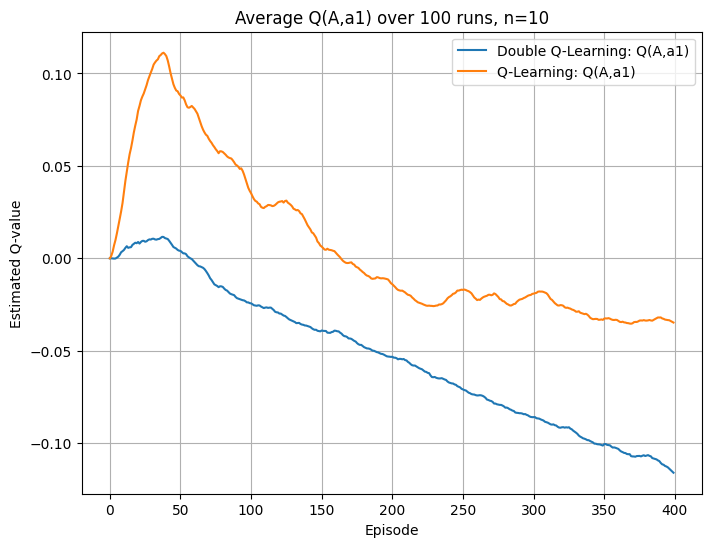

In [14]:
# -----------------------------------------------------------------------
# The MDP: States A,B and actions a1,a2,b1,...,bn (don't modify anything anymore, just run to get the graphs)
# -----------------------------------------------------------------------
@dataclass(frozen=True)
class P1State:
    """
    The MDP state, storing whether we are in "A" or "B".
    """
    name: str

class P1MDP(MarkovDecisionProcess[P1State, str]):
    
    def __init__(self, n: int):
        self.n = n

    def actions(self, state: NonTerminal[P1State]) -> Iterable[str]:
        """
        Return the actions available from this state.
          - if state is A => ["a1", "a2"]
          - if state is B => ["b1", ..., "bn"]
        """
        if state.state.name == "A":
            return ["a1", "a2"]
        else:
            return [f"b{i}" for i in range(1, self.n+1)]
    
    def step(
        self,
        state: NonTerminal[P1State],
        action: str
    ) -> Distribution[Tuple[State[P1State], float]]:
        """
        Return the distribution of (next state, reward) from (state, action):
          - A + a1 => reward 0, next state B
          - A + a2 => reward 0, next state terminal
          - B + b_i => reward ~ Normal(-0.1,1), next state terminal
        """
        if state.state.name == "A":
            if action == "a1":
                return Constant((NonTerminal(P1State("B")), 0.0))
            else:
                return Constant((Terminal(P1State("T")), 0.0))
        else:
            # For B + b_i => reward ~ N(-0.1,1), then terminal
            def sampler():
                r = np.random.normal(loc=-0.1, scale=1.0)
                return (Terminal(P1State("T")), r)
            return SampledDistribution(sampler)

def run_double_q_once(mdp, start_dist, gamma=1.0, episodes=400):
    """
    Runs one 'chain' of Double Q-Learning for 'episodes' episodes,
    returning a list of Q-values for Q((A,a1)) at the end of each episode.
    """
    dq_iter = double_q_learning(mdp, start_dist, gamma)  # generator
    vals = []
    for _ in range(episodes):
        Q1 = next(dq_iter)
        # record Q1((A,a1)) each time
        qA1 = Q1((NonTerminal(P1State("A")), "a1"))
        vals.append(qA1)
    return vals

def run_q_once(mdp, start_dist, gamma=1.0, episodes=400):
    """
    Same but for standard Q-Learning
    """
    q_iter = q_learning(mdp, start_dist, gamma)
    vals = []
    for _ in range(episodes):
        Q = next(q_iter)
        qA1 = Q((NonTerminal(P1State("A")), "a1"))
        vals.append(qA1)
    return vals

def main():
    # For reproducibility
    random.seed(0)
    np.random.seed(0)

    n = 10
    mdp = P1MDP(n)
    # Always start in A, as a NonTerminal
    start_dist = Constant(NonTerminal(P1State("A")))

    N_RUNS = 100
    N_EPISODES = 400

    all_dbl = []
    all_std = []

    for _ in range(N_RUNS):
        dbl_vals = run_double_q_once(mdp, start_dist, gamma=1.0, episodes=N_EPISODES)
        std_vals = run_q_once(mdp, start_dist, gamma=1.0, episodes=N_EPISODES)
        all_dbl.append(dbl_vals)
        all_std.append(std_vals)

    arr_dbl = np.array(all_dbl)
    arr_std = np.array(all_std)

    avg_dbl = np.mean(arr_dbl, axis=0)
    avg_std = np.mean(arr_std, axis=0)

    plt.figure(figsize=(8,6))
    plt.plot(avg_dbl, label='Double Q-Learning: Q(A,a1)')
    plt.plot(avg_std, label='Q-Learning: Q(A,a1)')
    plt.xlabel('Episode')
    plt.ylabel('Estimated Q-value')
    plt.title('Average Q(A,a1) over 100 runs, n=10')
    plt.legend()
    plt.grid(True)
    plt.show()

if __name__ == "__main__":
    main()

## (4.1) Compare Q-Learning and Double Q-Learning

Standard Q-Learning tends to **overestimate** action values early in training because updates use a max over noisy estimates. Estimates drift downward with more data but remain upward biased in finite samples.

Double Q-Learning reduces this early overestimation and converges closer to the true value by reducing optimism in the bootstrap target.

---

## (4.2) Why Q-Learning Exhibits Maximization Bias

Q-Learning uses
$$
r+\gamma\max_{a'}Q(s',a').
$$

If
$$
Q(s',a')=Q^*(s',a')+\varepsilon_{a'},
$$
then even when
$$
\mathbb{E}[\varepsilon_{a'}]=0,
$$
we have
$$
\mathbb{E}[\max_{a'}\varepsilon_{a'}]>0,
$$
so
$$
\mathbb{E}[\max_{a'}Q(s',a')]>\max_{a'}Q^*(s',a').
$$

The max operator selects positive noise more often, creating systematic overestimation.

---

## (4.3) Advantages and Drawbacks of Double Q-Learning

Double Q-Learning reduces maximization bias by maintaining two estimators and separating action selection from evaluation. This improves stability in stochastic environments.

Possible drawbacks:

- increased memory usage (two Q-tables)
- slightly slower learning in low-noise settings
- smaller gains in deterministic environments